# PCOS Detection: Multi-Modal Research Notebook
### Tabular Clinical Data + Ultrasound Image Classification
**Contributions:** Age-Stratified Analysis · Hormonal Root Cause via SHAP · Grad-CAM Cyst Localization

---
## Table of Contents
- **PART 1 — Tabular Dataset**
  - [1. Setup & Imports](#setup)
  - [2. Load & Inspect Data](#load)
  - [3. Preprocessing](#preprocess)
  - [4. Exploratory Data Analysis (EDA)](#eda)
  - [5. Age-Stratified Analysis ★](#age)
  - [6. Model Training](#models)
  - [7. Model Evaluation & Comparison](#eval)
  - [8. SHAP Root Cause Analysis ★](#shap)
- **PART 2 — Ultrasound Image Dataset**
  - [9. Image Setup & Paths](#imgsetup)
  - [10. Image Preprocessing & EDA](#imgpreprocess)
  - [11. CNN Model Training](#cnn)
  - [12. CNN Evaluation & Grad-CAM ★](#gradcam)
- **PART 3 — Final Comparison**
  - [13. Combined Results Summary](#summary)

---
# PART 1 — Tabular Clinical Dataset
**Dataset:** 2000 patients · 44 features · PCOS (Y/N) binary classification

## 1. Setup & Imports <a id='setup'></a>

In [1]:
# Install any missing packages (uncomment if needed)
# !pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn
# !pip install torch torchvision timm grad-cam Pillow

import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Models — Tabular
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# SHAP
import shap

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = {'pcos': '#E05C5C', 'healthy': '#5C9AE0', 'accent': '#2ECC71'}

print('All imports successful ✓')

All imports successful ✓


## 2. Load & Inspect Data <a id='load'></a>

In [2]:
# ── CHANGE THIS PATH IF NEEDED ──────────────────────────────────
CSV_PATH = '/content/PCOS_extended_dataset.csv'   # put your CSV filename here
# ─────────────────────────────────────────────────────────────────

df_raw = pd.read_csv(CSV_PATH)

# Strip all column-name whitespace (your file has several padded names)
df_raw.columns = df_raw.columns.str.strip()

print(f'Shape: {df_raw.shape}')
print(f'\nTarget distribution:')
vc = df_raw['PCOS (Y/N)'].value_counts()
print(f'  Non-PCOS (0): {vc[0]}  ({vc[0]/len(df_raw)*100:.1f}%)')
print(f'  PCOS     (1): {vc[1]}  ({vc[1]/len(df_raw)*100:.1f}%)')
print(f'\nMissing values:')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  None found ✓')
df_raw.head(3)

Shape: (2000, 44)

Target distribution:
  Non-PCOS (0): 1392  (69.6%)
  PCOS     (1): 608  (30.4%)

Missing values:
Marraige Status (Yrs)    3
dtype: int64


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691


## 3. Preprocessing <a id='preprocess'></a>

In [13]:
df = df_raw.copy()

# Step 1: Drop identifiers
df.drop(columns=['Sl. No', 'Patient File No.'], inplace=True)
print('Step 1: Dropped identifier columns ✓')

# Step 2: Fix ambiguous column names
df.rename(columns={
    'I   beta-HCG(mIU/mL)' : 'beta_HCG_I(mIU/mL)',
    'II    beta-HCG(mIU/mL)': 'beta_HCG_II(mIU/mL)'
}, inplace=True)
print('Step 2: Renamed ambiguous columns ✓')

# Define hormonal columns
hormonal_cols = ['FSH(mIU/mL)', 'LH(mIU/mL)', 'AMH(ng/mL)',
                 'TSH (mIU/L)', 'PRL(ng/mL)', 'PRG(ng/mL)']

# All columns that should be numeric (including hormonal)
numeric_cols = [
    'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI',
    'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)',
    'Cycle length(days)', 'Marraige Status (Yrs)',
    'No. of abortions', 'beta_HCG_I(mIU/mL)', 'beta_HCG_II(mIU/mL)',
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)',
    'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)',
    'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)',
    'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)',
    'Follicle No. (L)', 'Follicle No. (R)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'
]

# Convert all numeric columns to numeric, coerce errors to NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values in numeric columns (median)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# ================================================================
# FIX: Binary Y/N column encoding (replaces the broken block)
# ================================================================
# Root cause: .map({'0':0,'1':1,'Y':1,'N':0}) fails on integer-
# valued columns because int 0 ≠ str '0' → all NaN → all 0 after
# fillna → constant column → NaN correlation → blank heatmap.
# ================================================================

binary_cols = ['Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
               'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
               'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

for col in binary_cols:
    # Step 1: stringify so map always works regardless of original dtype
    s = df[col].astype(str).str.strip().str.upper()
    # Step 2: map all possible representations
    s = s.map({'0': 0, '1': 1, 'Y': 1, 'N': 0,
               '0.0': 0, '1.0': 1,          # float-as-string edge case
               'TRUE': 1, 'FALSE': 0,
               'YES': 1, 'NO': 0})
    # Step 3: anything still NaN → try numeric parse, else 0
    df[col] = pd.to_numeric(s, errors='coerce').fillna(0).astype(int)

# Quick sanity check — should show 0s and 1s only, no NaNs
print("Binary column value counts (should be only 0 and 1):")
for col in binary_cols:
    vc = df[col].value_counts().to_dict()
    nulls = df[col].isnull().sum()
    print(f"  {col:<30} {vc}  | NaNs: {nulls}")


# Outlier capping (3×IQR) only for hormonal columns
for col in hormonal_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
    df[col] = df[col].clip(lower, upper)
print('Step 3: Hormonal columns – converted, imputed, and outliers capped ✓')

# (No separate imputation needed for 'Marraige Status (Yrs)' or 'Fast food (Y/N)' – already handled above)

# Step 4: Feature Engineering
df['LH_FSH_ratio'] = df['LH(mIU/mL)'] / (df['FSH(mIU/mL)'] + 1e-6)
df['BMI_cat'] = pd.cut(df['BMI'], bins=[0,18.5,24.9,29.9,100],
                       labels=['Underweight','Normal','Overweight','Obese']).astype(str)
df['Age_group'] = pd.cut(df['Age (yrs)'], bins=[0,20,25,30,35,100],
                         labels=['<20','20-25','26-30','31-35','>35'])
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['BMI_cat_enc'] = le.fit_transform(df['BMI_cat'])
print('Step 4: Feature engineering done ✓')

# Step 5: Prepare X, y
age_groups_all = df['Age_group'].copy()
DROP_FOR_MODEL = ['PCOS (Y/N)', 'Age_group', 'BMI_cat']
X = df.drop(columns=DROP_FOR_MODEL)
y = df['PCOS (Y/N)']

print(f'\nFinal feature matrix: {X.shape}')
print(f'Target: {y.sum()} PCOS, {(y==0).sum()} non-PCOS')

Step 1: Dropped identifier columns ✓
Step 2: Renamed ambiguous columns ✓
Binary column value counts (should be only 0 and 1):
  Pregnant(Y/N)                  {0: 1237, 1: 763}  | NaNs: 0
  Weight gain(Y/N)               {0: 1239, 1: 761}  | NaNs: 0
  hair growth(Y/N)               {0: 1451, 1: 549}  | NaNs: 0
  Skin darkening (Y/N)           {0: 1420, 1: 580}  | NaNs: 0
  Hair loss(Y/N)                 {0: 1113, 1: 887}  | NaNs: 0
  Pimples(Y/N)                   {0: 1046, 1: 954}  | NaNs: 0
  Fast food (Y/N)                {1: 1034, 0: 966}  | NaNs: 0
  Reg.Exercise(Y/N)              {0: 1485, 1: 515}  | NaNs: 0
Step 3: Hormonal columns – converted, imputed, and outliers capped ✓
Step 4: Feature engineering done ✓

Final feature matrix: (2000, 43)
Target: 608 PCOS, 1392 non-PCOS


In [14]:
# ── Step 7: Stratified Train/Test Split ──────────────────────────
# Stratify by PCOS label to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Track age groups for the test set (for stratified analysis later)
age_test = age_groups_all.iloc[y_test.index].values

# ── Step 8: Feature Scaling ───────────────────────────────────────
# Needed for Logistic Regression; doesn't hurt tree-based models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_sc  = scaler.transform(X_test)

# ── Step 9: SMOTE on training set ONLY ───────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'Train (before SMOTE): {y_train.value_counts().to_dict()}')
print(f'Train (after  SMOTE): {pd.Series(y_train_sm).value_counts().to_dict()}')
print(f'Test  (unchanged)  : {y_test.value_counts().to_dict()}')
print('\nPreprocessing pipeline complete ✓')

Train (before SMOTE): {0: 1114, 1: 486}
Train (after  SMOTE): {0: 1114, 1: 1114}
Test  (unchanged)  : {0: 278, 1: 122}

Preprocessing pipeline complete ✓


## 4. Exploratory Data Analysis (EDA) <a id='eda'></a>

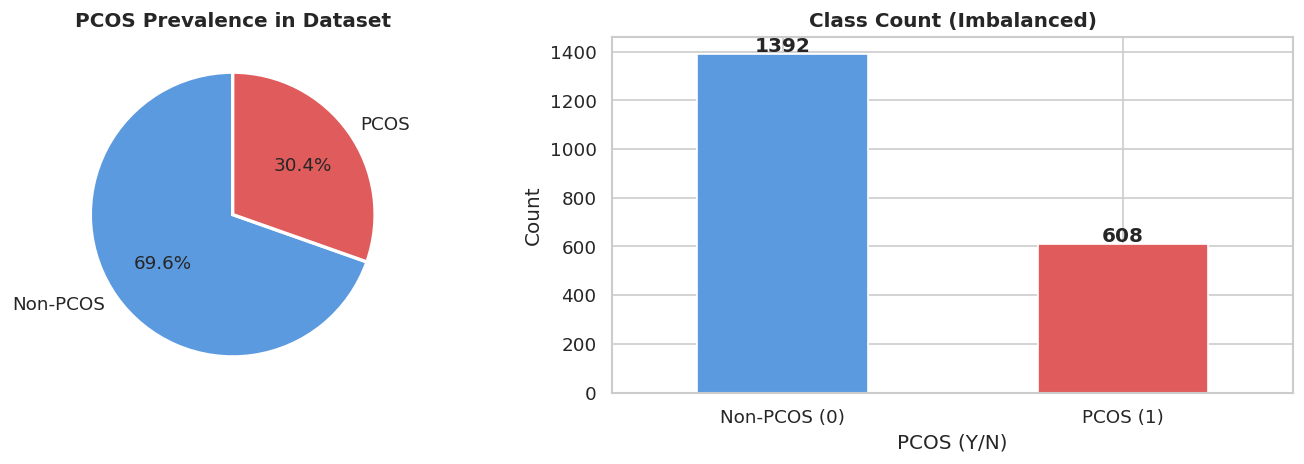

In [15]:
# ── 4.1  Target class distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie
ax = axes[0]
counts = y.value_counts()
ax.pie(counts, labels=['Non-PCOS','PCOS'],
       colors=[COLORS['healthy'], COLORS['pcos']],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('PCOS Prevalence in Dataset', fontweight='bold')

# Bar by group
ax = axes[1]
counts.plot(kind='bar', ax=ax,
            color=[COLORS['healthy'], COLORS['pcos']],
            edgecolor='white', width=0.5)
ax.set_xticklabels(['Non-PCOS (0)', 'PCOS (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Class Count (Imbalanced)', fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            int(bar.get_height()), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', bbox_inches='tight')
plt.show()

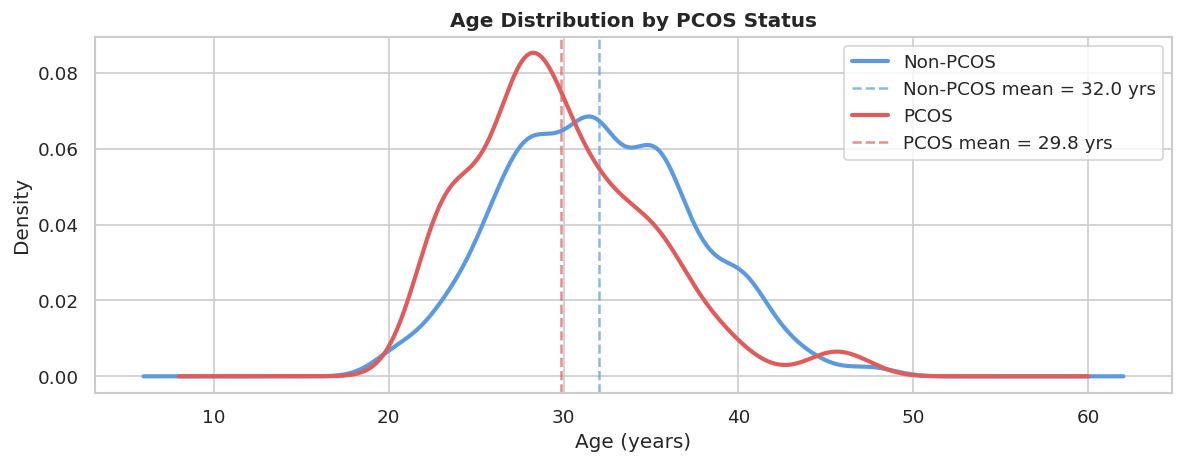

In [16]:
# ── 4.2  Age distribution by PCOS status ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for label, color, name in [(0, COLORS['healthy'], 'Non-PCOS'),
                            (1, COLORS['pcos'],    'PCOS')]:
    subset = df[df['PCOS (Y/N)'] == label]['Age (yrs)']
    subset.plot(kind='kde', ax=ax, color=color, linewidth=2.5, label=name)
    ax.axvline(subset.mean(), color=color, linestyle='--', alpha=0.7,
               label=f'{name} mean = {subset.mean():.1f} yrs')

ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by PCOS Status', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_02_age_distribution.png', bbox_inches='tight')
plt.show()

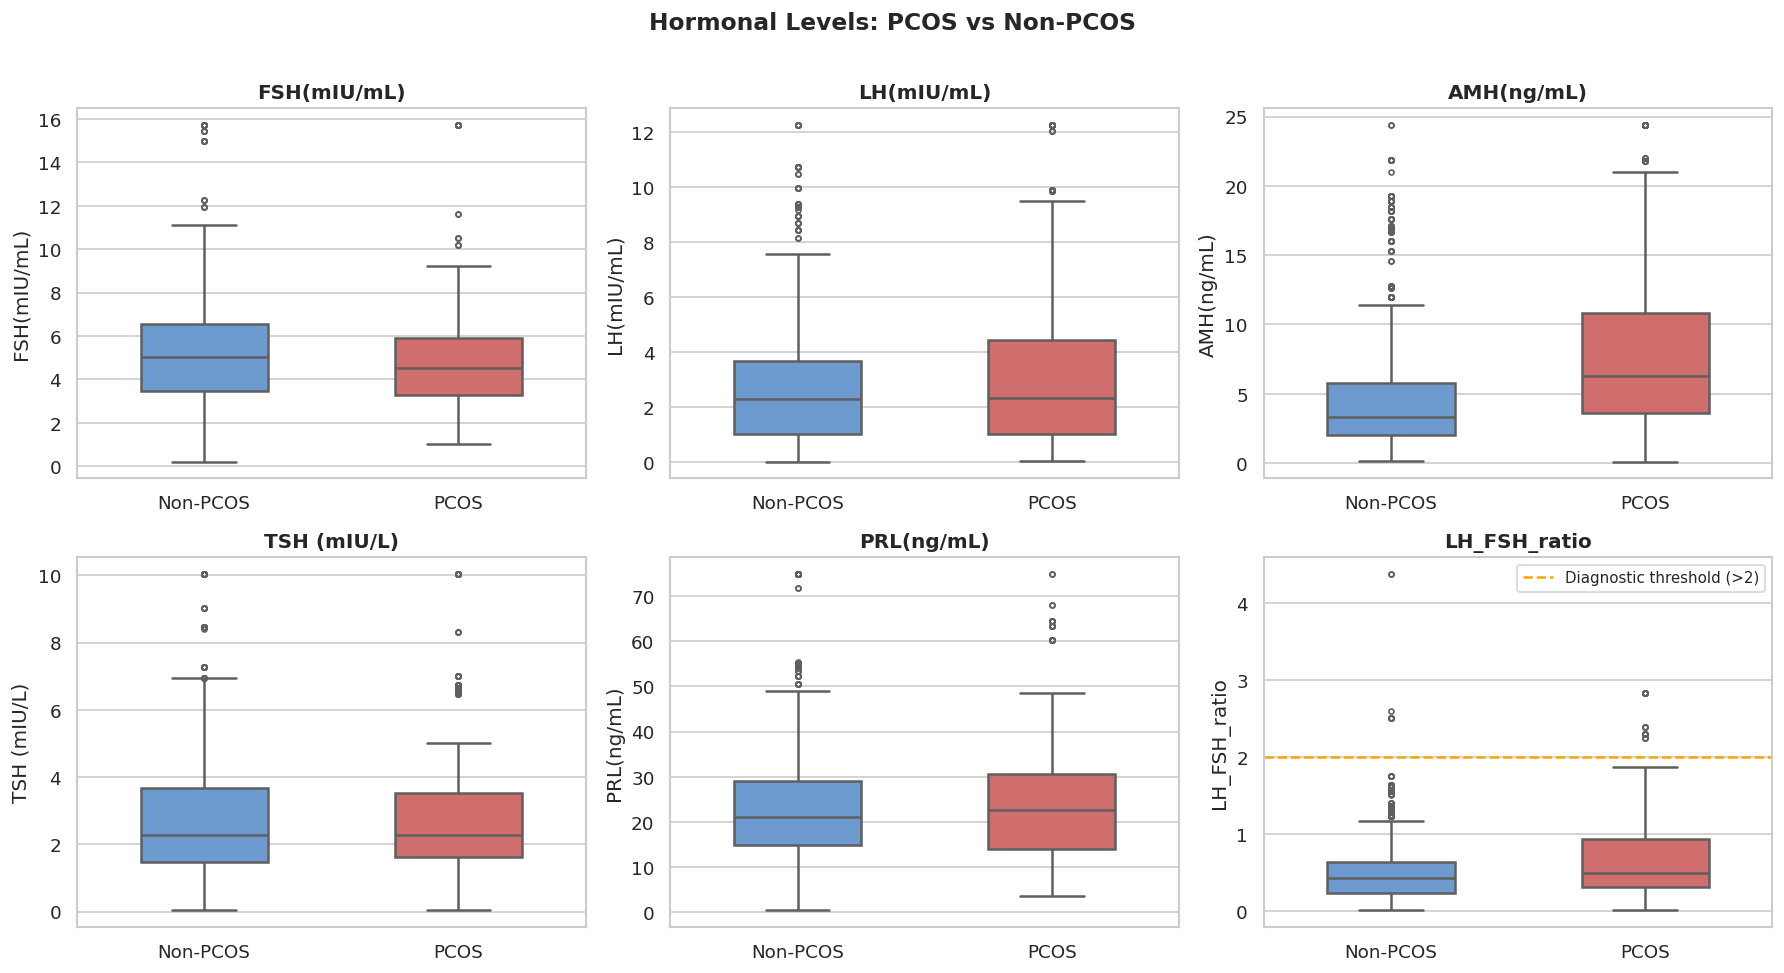

In [17]:
# ── 4.3  Hormonal boxplots ────────────────────────────────────────
hormones = ['FSH(mIU/mL)', 'LH(mIU/mL)', 'AMH(ng/mL)',
            'TSH (mIU/L)', 'PRL(ng/mL)', 'LH_FSH_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(hormones):
    data_plot = df[['PCOS (Y/N)', col]].copy()
    data_plot['PCOS Status'] = data_plot['PCOS (Y/N)'].map({0:'Non-PCOS', 1:'PCOS'})
    sns.boxplot(data=data_plot, x='PCOS Status', y=col, ax=axes[i],
                palette={'Non-PCOS': COLORS['healthy'], 'PCOS': COLORS['pcos']},
                width=0.5, linewidth=1.5, fliersize=3)
    if col == 'LH_FSH_ratio':
        axes[i].axhline(2.0, color='orange', linestyle='--', linewidth=1.5,
                        label='Diagnostic threshold (>2)')
        axes[i].legend(fontsize=9)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Hormonal Levels: PCOS vs Non-PCOS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_03_hormonal_boxplots.png', bbox_inches='tight')
plt.show()


All 43 columns have valid correlations ✓


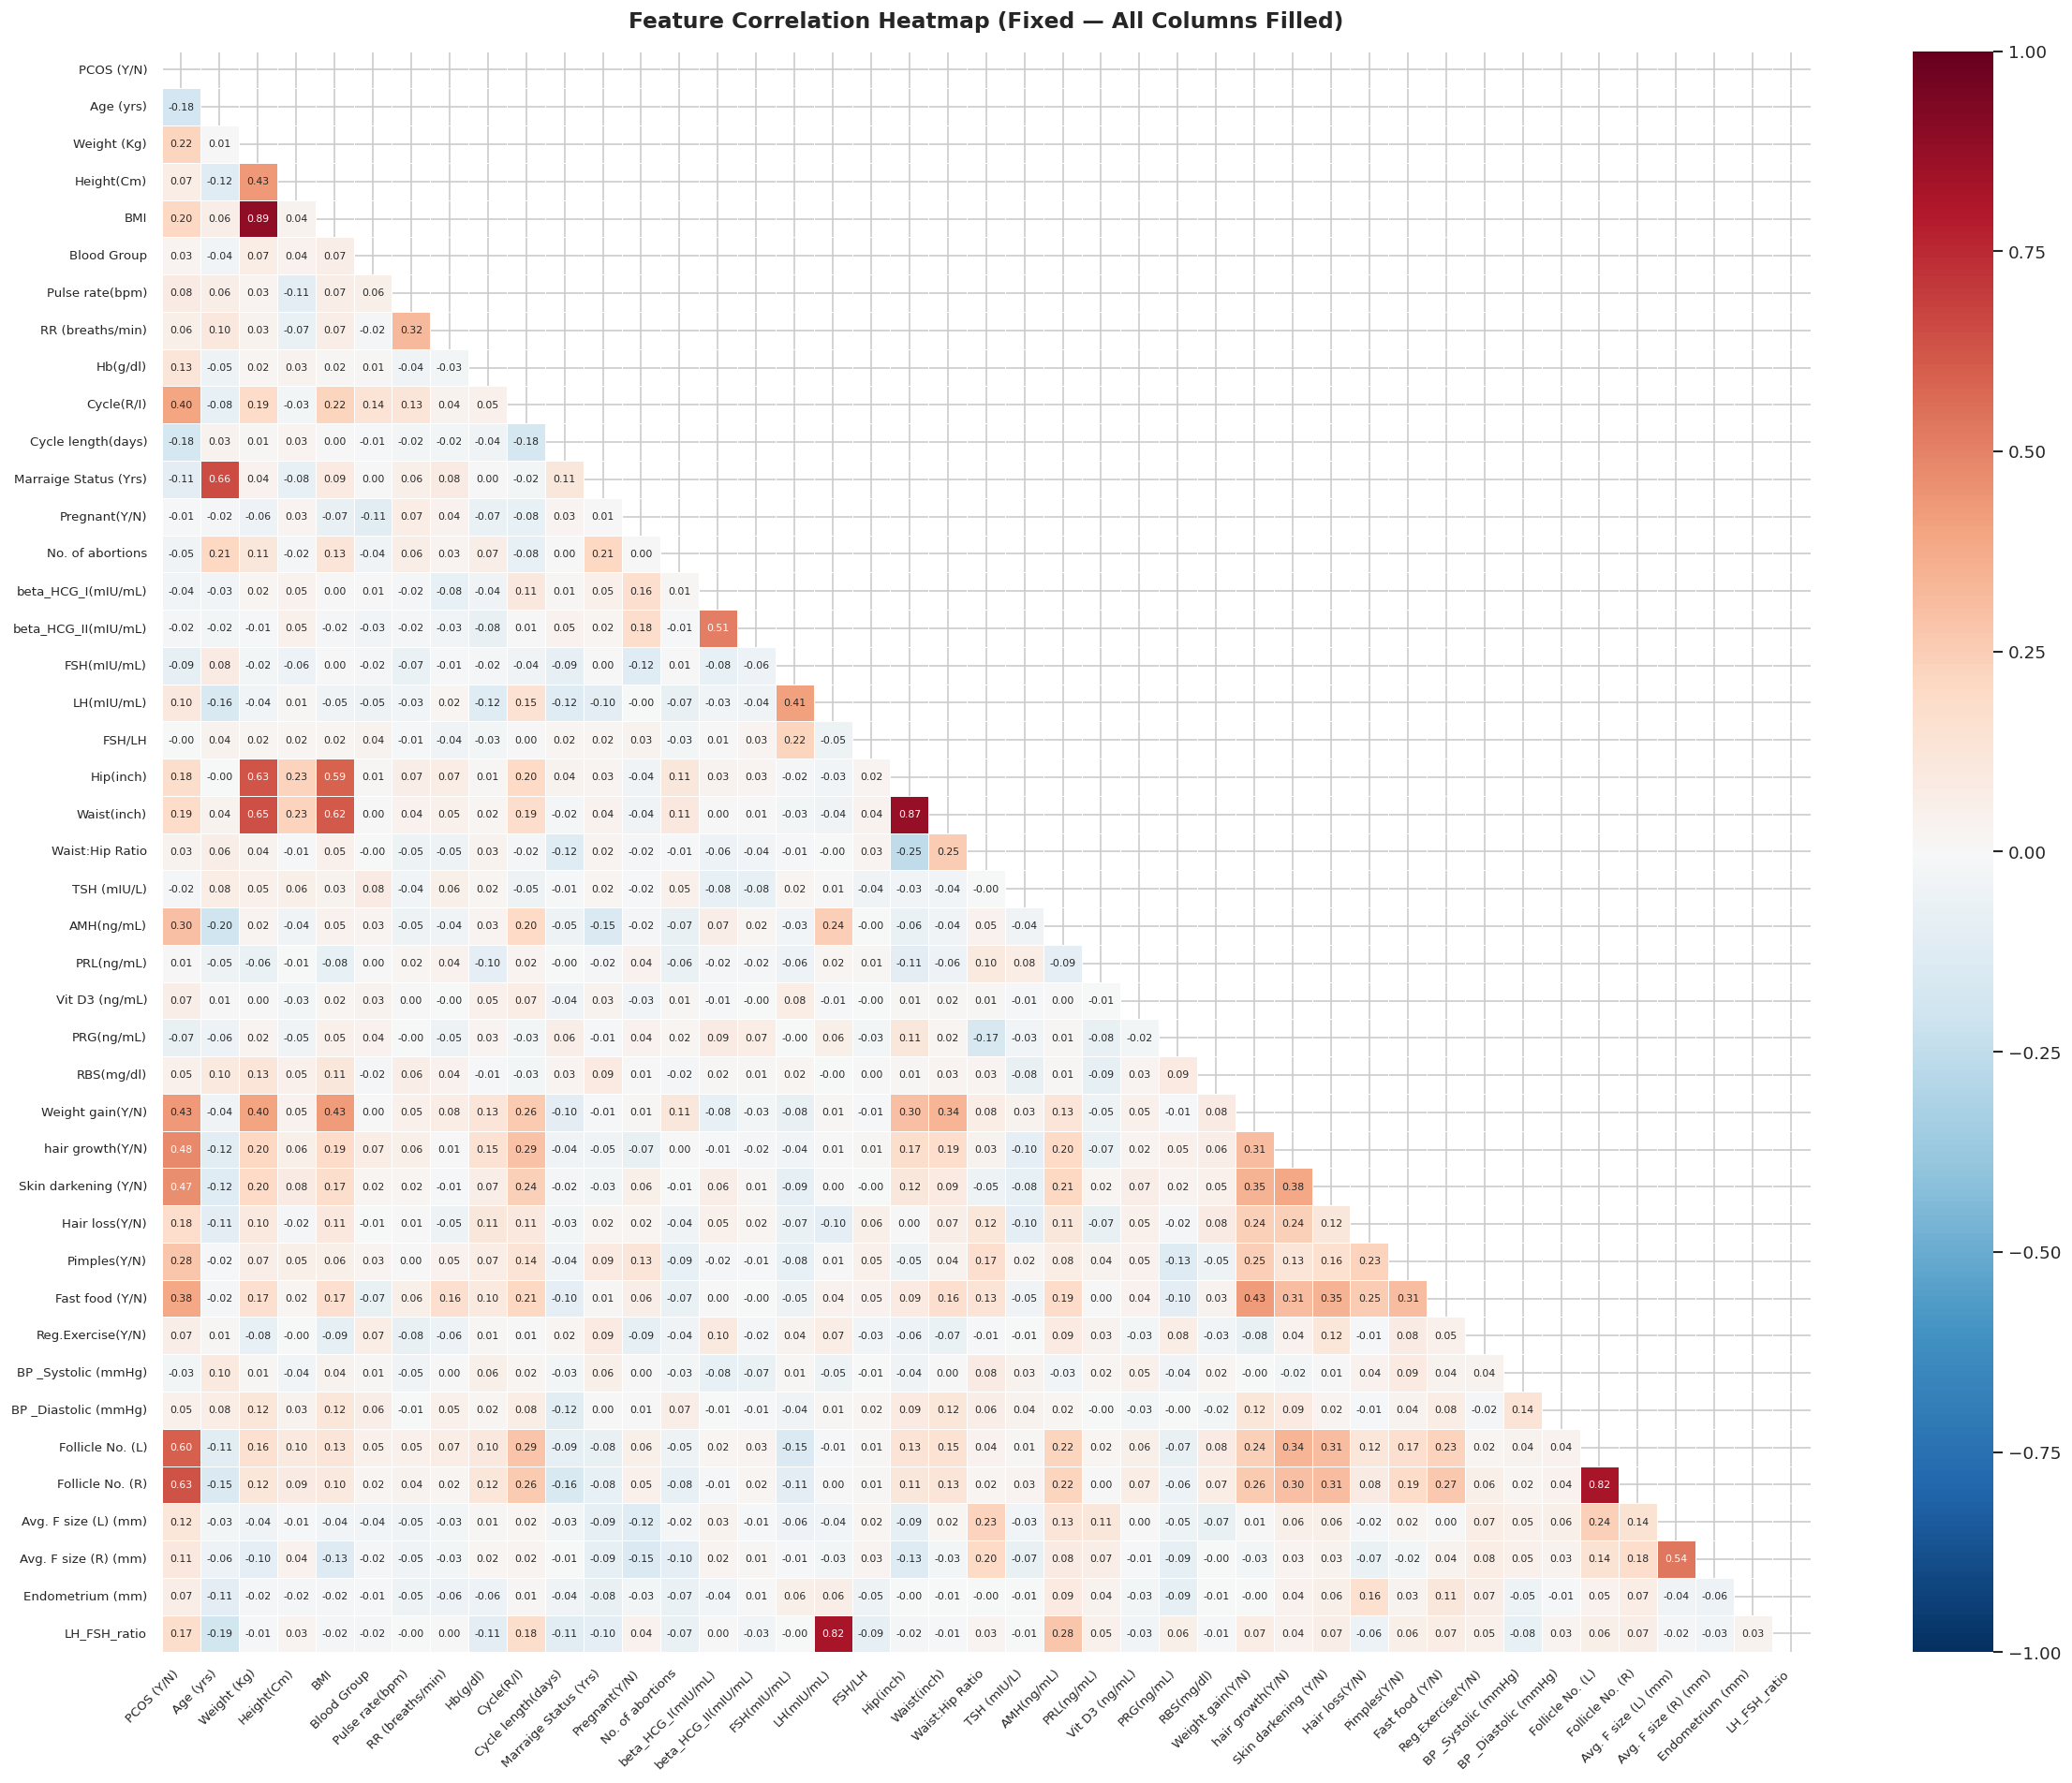

Fixed heatmap saved ✓


In [18]:
# ── 4.4  Correlation heatmap ──────────────────────────────────────
# Recompute correlation on fully numeric, non-constant columns
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Drop columns that are constant (std == 0) — they give NaN correlation
non_constant = numeric_df.columns[numeric_df.std() > 0]
numeric_df = numeric_df[non_constant]

# Drop identifier / engineered-encoding column
numeric_df = numeric_df.drop(columns=['BMI_cat_enc'], errors='ignore')

corr = numeric_df.corr()

# Confirm no all-NaN rows/columns remain
blank_cols = corr.columns[corr.isnull().all()].tolist()
if blank_cols:
    print(f"\nWARNING: still blank after fix → {blank_cols}")
else:
    print(f"\nAll {len(corr)} columns have valid correlations ✓")

# ── Plot fixed heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle hidden

sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6.5},
    linewidths=0.4,
    ax=ax,
    vmin=-1, vmax=1,
    square=False
)

ax.set_title('Feature Correlation Heatmap (Fixed — All Columns Filled)',
             fontsize=14, fontweight='bold', pad=15)

# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('eda_04_correlation_heatmap_FIXED.png', bbox_inches='tight', dpi=150)
plt.show()
print("Fixed heatmap saved ✓")


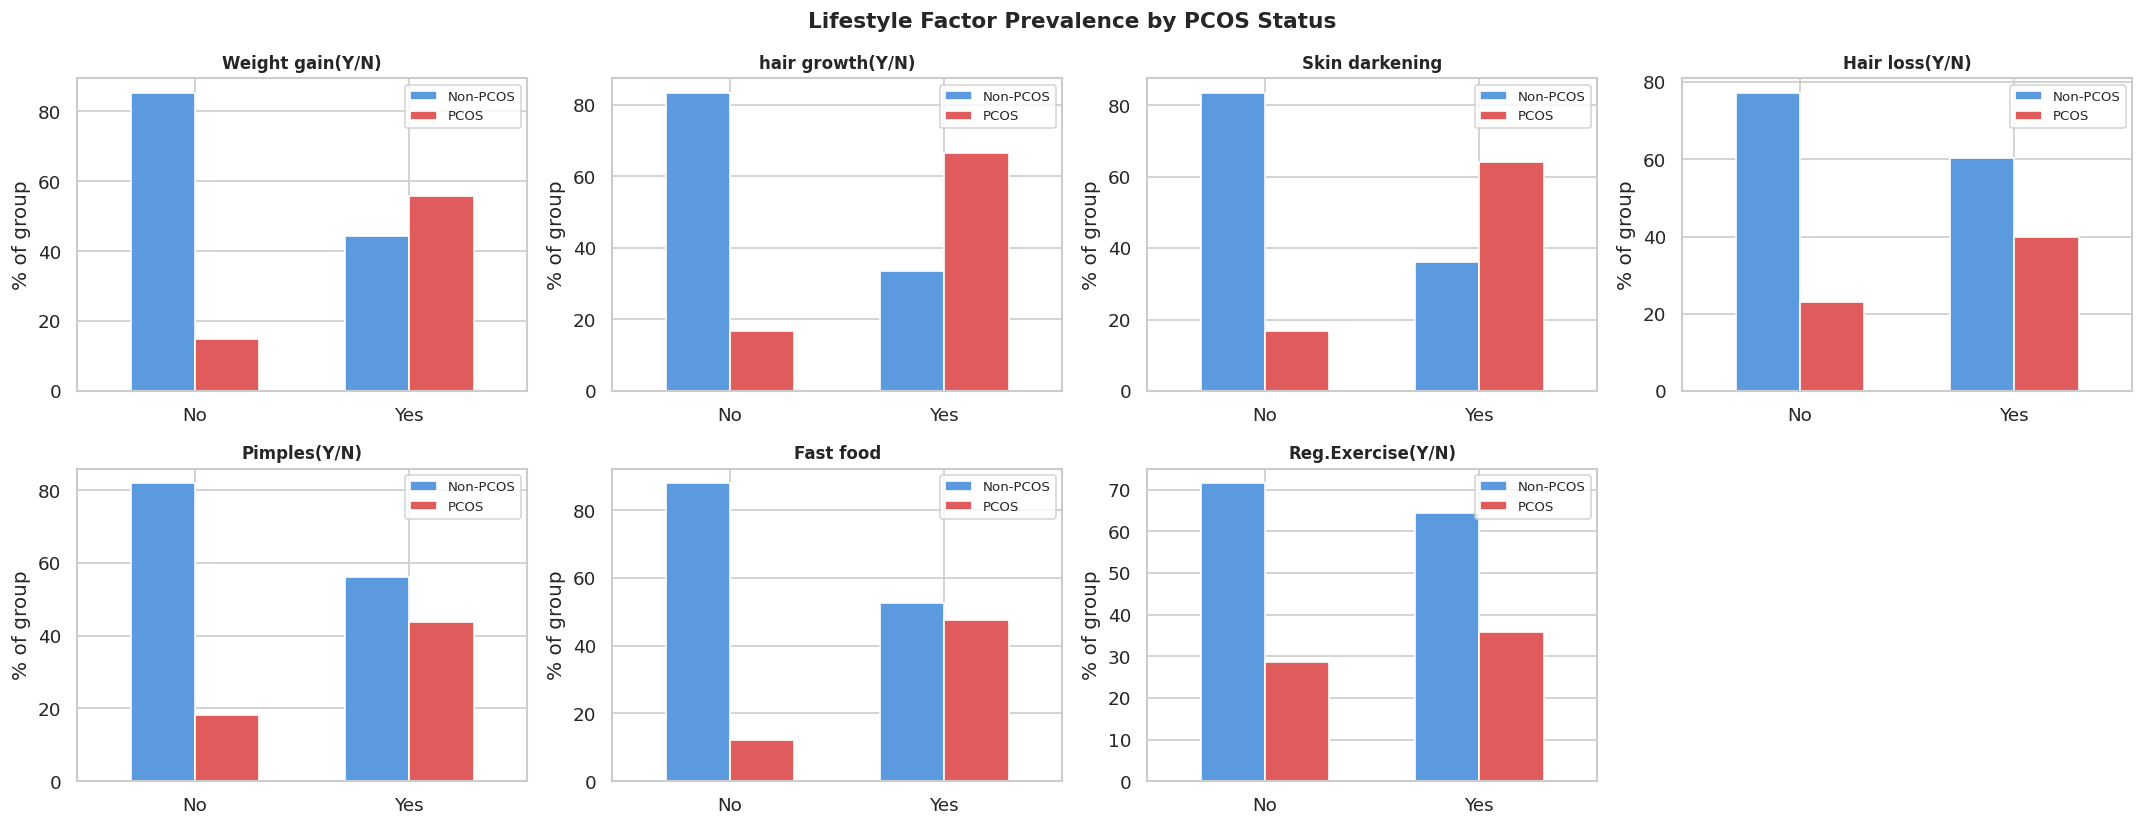

In [19]:
# ── 4.5  Lifestyle factors ────────────────────────────────────────
lifestyle = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
             'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(lifestyle):
    ct = pd.crosstab(df[col], df['PCOS (Y/N)'], normalize='index') * 100
    ct.columns = ['Non-PCOS', 'PCOS']
    ct.index = ['No','Yes']
    ct.plot(kind='bar', ax=axes[i],
            color=[COLORS['healthy'], COLORS['pcos']],
            edgecolor='white', width=0.6, rot=0)
    axes[i].set_title(col.replace(' (Y/N)',''), fontweight='bold', fontsize=10)
    axes[i].set_ylabel('% of group')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Lifestyle Factor Prevalence by PCOS Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_lifestyle_factors.png', bbox_inches='tight')
plt.show()

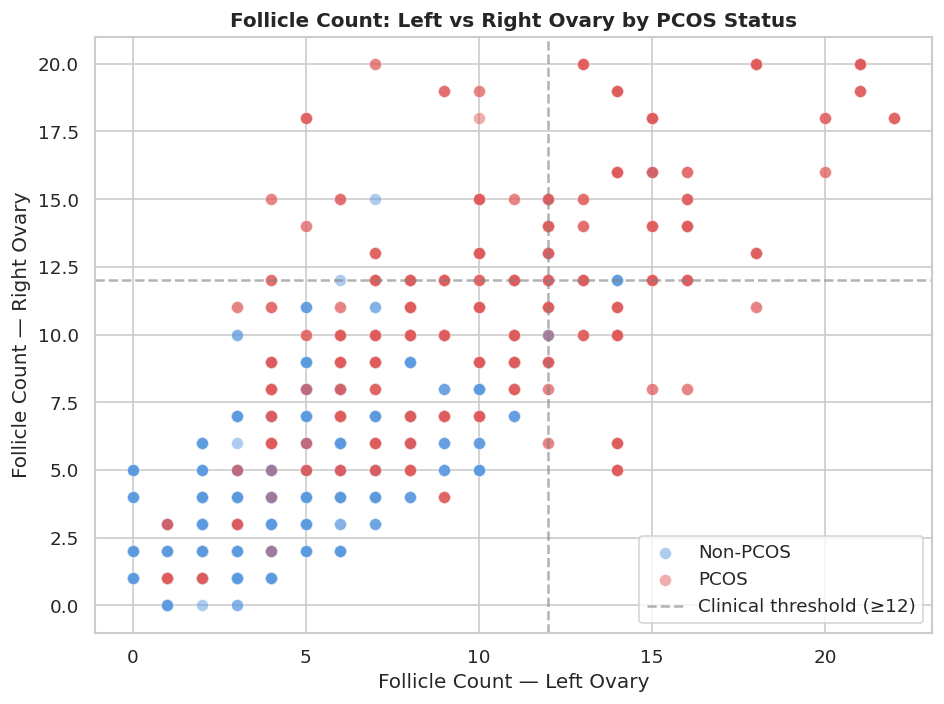

In [20]:
# ── 4.6  Follicle count scatter ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for label, color, name in [(0, COLORS['healthy'], 'Non-PCOS'),
                            (1, COLORS['pcos'],    'PCOS')]:
    sub = df[df['PCOS (Y/N)'] == label]
    ax.scatter(sub['Follicle No. (L)'], sub['Follicle No. (R)'],
               c=color, alpha=0.5, label=name, edgecolors='white', linewidth=0.3, s=50)

ax.set_xlabel('Follicle Count — Left Ovary')
ax.set_ylabel('Follicle Count — Right Ovary')
ax.set_title('Follicle Count: Left vs Right Ovary by PCOS Status', fontweight='bold')
ax.axvline(12, color='grey', linestyle='--', alpha=0.6, label='Clinical threshold (≥12)')
ax.axhline(12, color='grey', linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('eda_06_follicle_scatter.png', bbox_inches='tight')
plt.show()

## 5. Age-Stratified Analysis ★ <a id='age'></a>
> **Novel Contribution:** Most PCOS studies report overall accuracy. We report performance broken down by age group, revealing where the model is weakest and how hormonal patterns shift with age.

PCOS Prevalence by Age Group:
           PCOS Count  Total  Prevalence (%)
Age_group                                   
<20                 0     14             0.0
20-25             129    260            49.6
26-30             245    673            36.4
31-35             148    603            24.5
>35                86    450            19.1


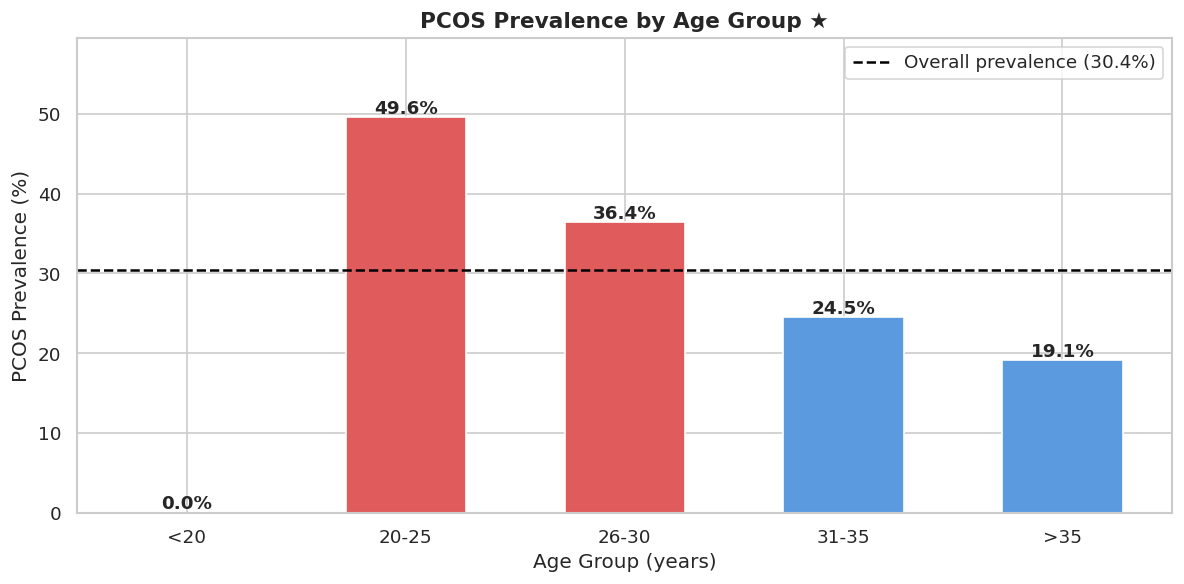

In [21]:
# ── 5.1  PCOS prevalence by age group ────────────────────────────
age_pcos = df.groupby('Age_group', observed=True)['PCOS (Y/N)'].agg(['sum','count'])
age_pcos['prevalence_%'] = (age_pcos['sum'] / age_pcos['count'] * 100).round(1)
age_pcos.columns = ['PCOS Count', 'Total', 'Prevalence (%)']
print('PCOS Prevalence by Age Group:')
print(age_pcos.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(age_pcos.index.astype(str), age_pcos['Prevalence (%)'],
              color=[COLORS['pcos'] if v > 30 else COLORS['healthy']
                     for v in age_pcos['Prevalence (%)']],
              edgecolor='white', width=0.55)
for bar, val in zip(bars, age_pcos['Prevalence (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Age Group (years)', fontsize=12)
ax.set_ylabel('PCOS Prevalence (%)', fontsize=12)
ax.set_title('PCOS Prevalence by Age Group ★', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(age_pcos['Prevalence (%)']) + 10)
ax.axhline(y.mean()*100, color='black', linestyle='--',
           label=f'Overall prevalence ({y.mean()*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('age_01_prevalence_by_group.png', bbox_inches='tight')
plt.show()

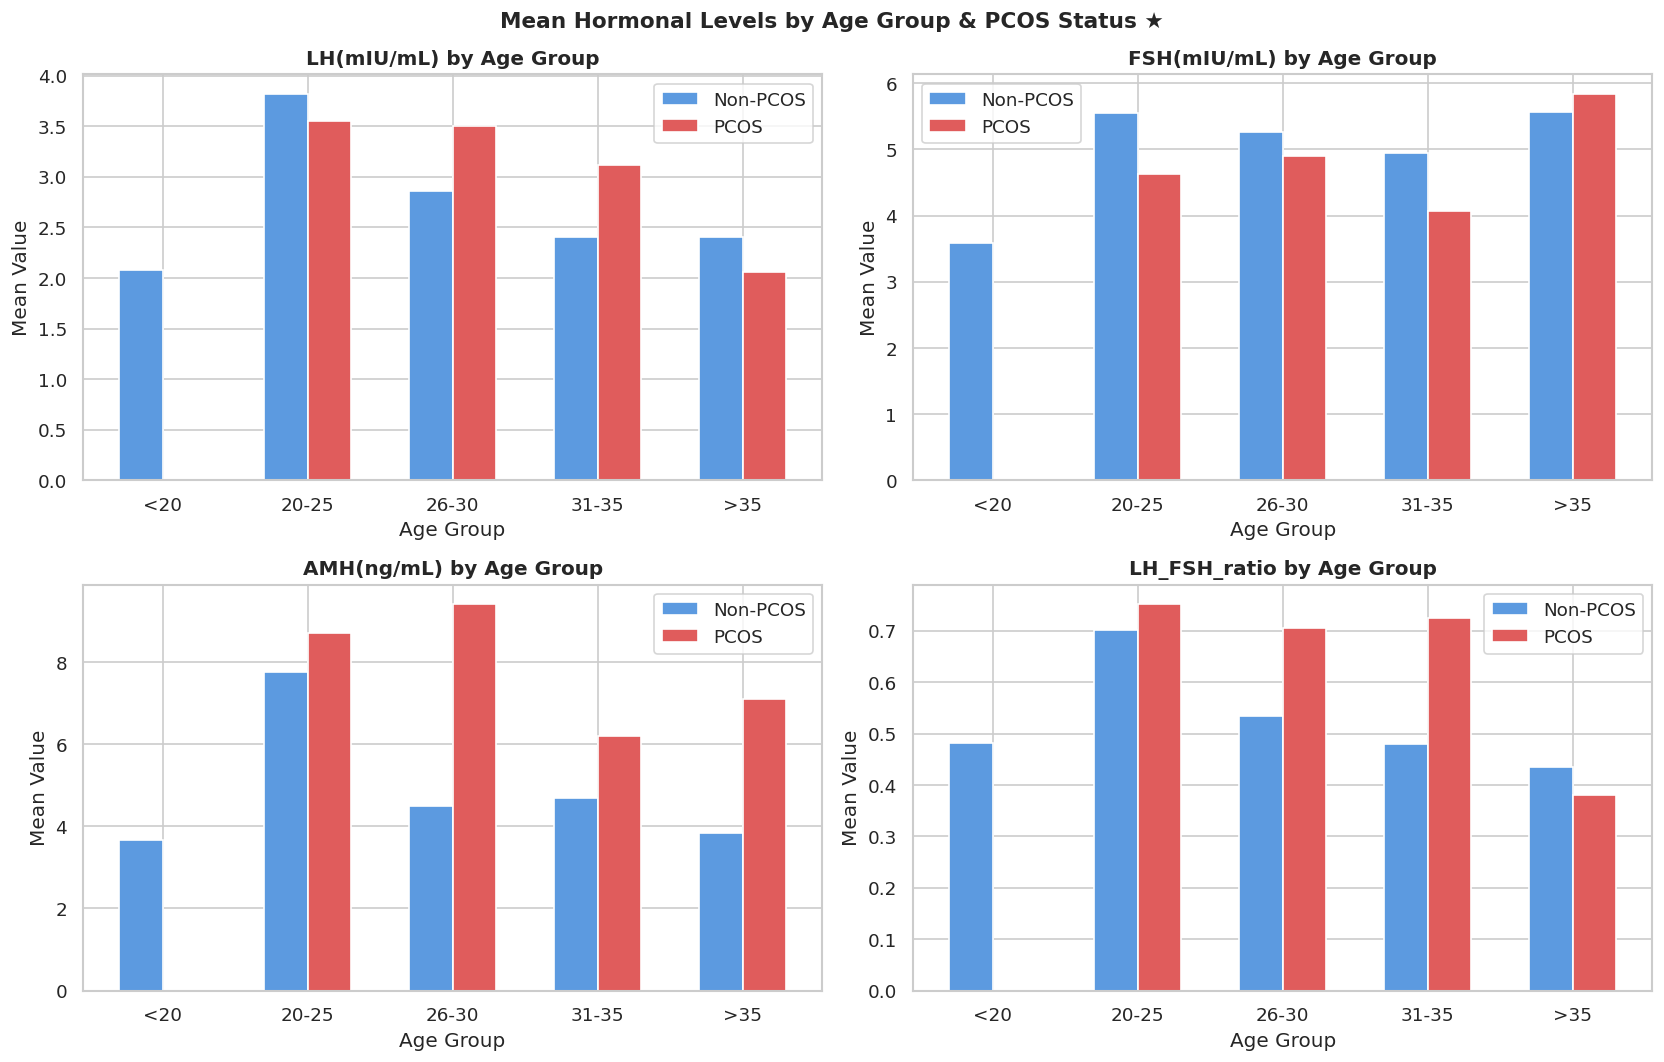

In [22]:
# ── 5.2  Hormonal profile by age group ───────────────────────────
key_hormones = ['LH(mIU/mL)', 'FSH(mIU/mL)', 'AMH(ng/mL)', 'LH_FSH_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, hormone in enumerate(key_hormones):
    grouped = df.groupby(['Age_group', 'PCOS (Y/N)'], observed=True)[hormone].mean().unstack()
    grouped.columns = ['Non-PCOS', 'PCOS']
    grouped.plot(kind='bar', ax=axes[i],
                 color=[COLORS['healthy'], COLORS['pcos']],
                 edgecolor='white', width=0.6, rot=0)
    axes[i].set_title(f'{hormone} by Age Group', fontweight='bold')
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel('Mean Value')
    axes[i].legend()

plt.suptitle('Mean Hormonal Levels by Age Group & PCOS Status ★',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('age_02_hormones_by_age.png', bbox_inches='tight')
plt.show()

## 6. Model Training — Three Classifiers <a id='models'></a>
| Model | Why Chosen |
|---|---|
| **XGBoost** | Best tabular performance + SHAP root-cause analysis |
| **Random Forest** | Robust ensemble, cross-validates feature importance |
| **Logistic Regression (L1)** | Interpretable baseline required for medical journals |

In [23]:
from sklearn.model_selection import StratifiedKFold

# ── Define models ─────────────────────────────────────────────────
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        use_label_encoder=False, eval_metric='logloss', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Logistic Regression (L1)': LogisticRegression(
        penalty='l1', solver='liblinear', C=0.5,
        class_weight='balanced', max_iter=1000, random_state=42
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}
trained_models = {}

print('Training models with 5-fold stratified cross-validation...\n')
for name, model in models.items():
    # Use SMOTE-balanced data for XGB (handles imbalance natively anyway)
    # Use scaled data for LR; unscaled still works for trees but scaled is fine
    cv_res = cross_validate(model, X_train_sm, y_train_sm,
                             cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = cv_res

    # Fit final model on full SMOTE train set
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model

    print(f'{name}:')
    print(f'  Accuracy : {cv_res["test_accuracy"].mean():.4f} ± {cv_res["test_accuracy"].std():.4f}')
    print(f'  Recall   : {cv_res["test_recall"].mean():.4f} ± {cv_res["test_recall"].std():.4f}')
    print(f'  F1       : {cv_res["test_f1"].mean():.4f} ± {cv_res["test_f1"].std():.4f}')
    print(f'  AUC-ROC  : {cv_res["test_roc_auc"].mean():.4f} ± {cv_res["test_roc_auc"].std():.4f}')
    print()

Training models with 5-fold stratified cross-validation...

XGBoost:
  Accuracy : 0.9969 ± 0.0030
  Recall   : 0.9973 ± 0.0036
  F1       : 0.9969 ± 0.0030
  AUC-ROC  : 0.9999 ± 0.0001

Random Forest:
  Accuracy : 0.9946 ± 0.0023
  Recall   : 0.9919 ± 0.0044
  F1       : 0.9946 ± 0.0023
  AUC-ROC  : 0.9999 ± 0.0001

Logistic Regression (L1):
  Accuracy : 0.9044 ± 0.0104
  Recall   : 0.9165 ± 0.0238
  F1       : 0.9055 ± 0.0107
  AUC-ROC  : 0.9641 ± 0.0077



## 7. Model Evaluation & Comparison <a id='eval'></a>

In [24]:
# ── 7.1  Test set evaluation ──────────────────────────────────────
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('\n=== Test Set Performance ===' )
print(results_df.to_string())
results_df


=== Test Set Performance ===
                          Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                   
XGBoost                     0.9875     0.9680  0.9918    0.9798   0.9999
Random Forest               0.9925     0.9837  0.9918    0.9878   0.9999
Logistic Regression (L1)    0.9175     0.8397  0.9016    0.8696   0.9651


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
XGBoost,0.9875,0.9680,0.9918,0.9798,0.9999
Random Forest,0.9925,0.9837,0.9918,0.9878,0.9999
Logistic Regression (L1),0.9175,0.8397,0.9016,0.8696,0.9651


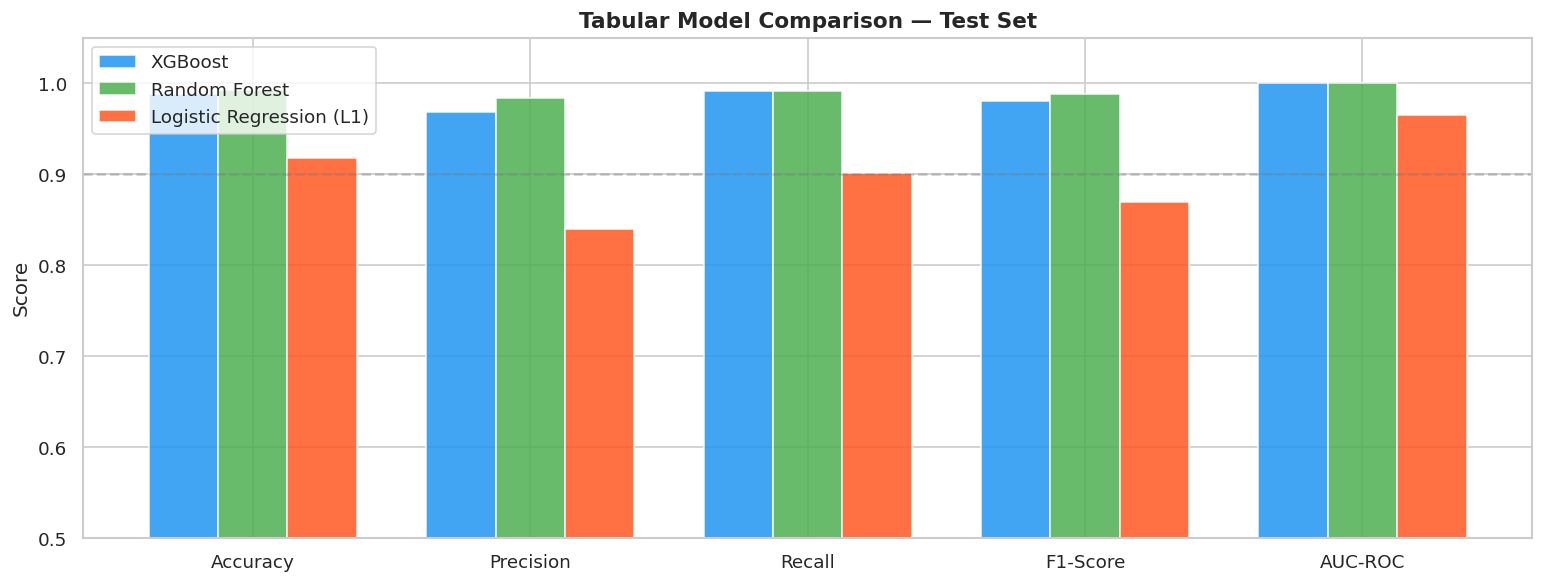

In [25]:
# ── 7.2  Bar chart comparison ─────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names = results_df.index.tolist()
x = np.arange(len(metrics))
width = 0.25
palette = ['#2196F3', '#4CAF50', '#FF5722']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (mname, color) in enumerate(zip(model_names, palette)):
    vals = results_df.loc[mname, metrics].values
    bars = ax.bar(x + i*width, vals, width, label=mname,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Tabular Model Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.9, color='grey', linestyle='--', alpha=0.4, label='0.9 threshold')
plt.tight_layout()
plt.savefig('eval_01_model_comparison.png', bbox_inches='tight')
plt.show()

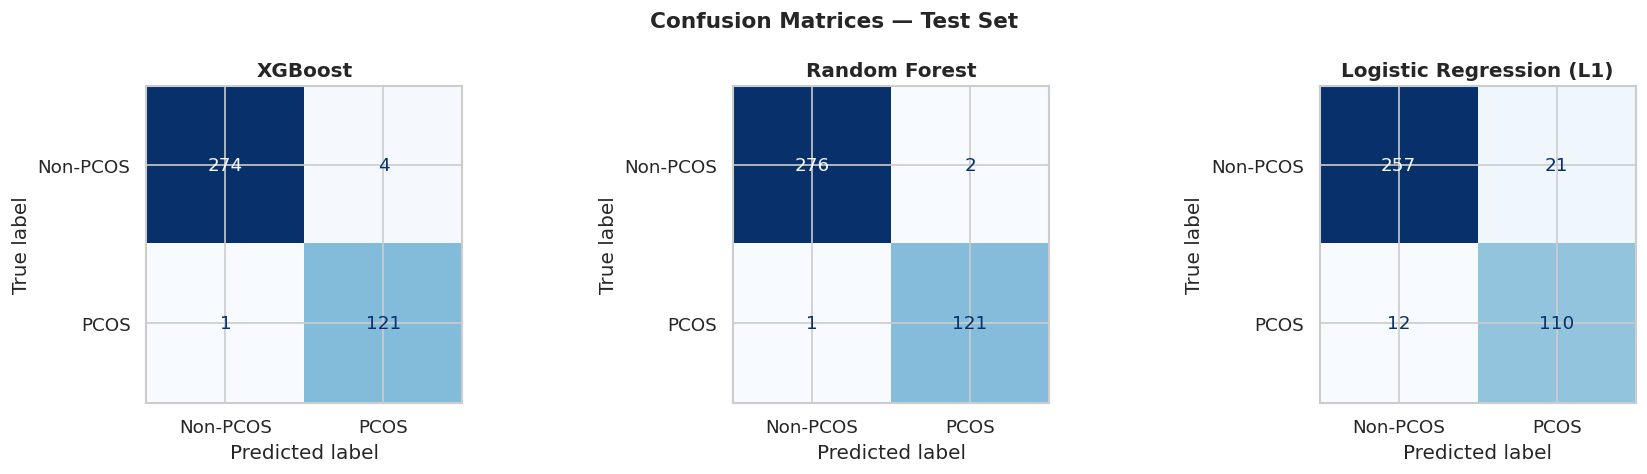

In [26]:
# ── 7.3  Confusion matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non-PCOS','PCOS']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_02_confusion_matrices.png', bbox_inches='tight')
plt.show()

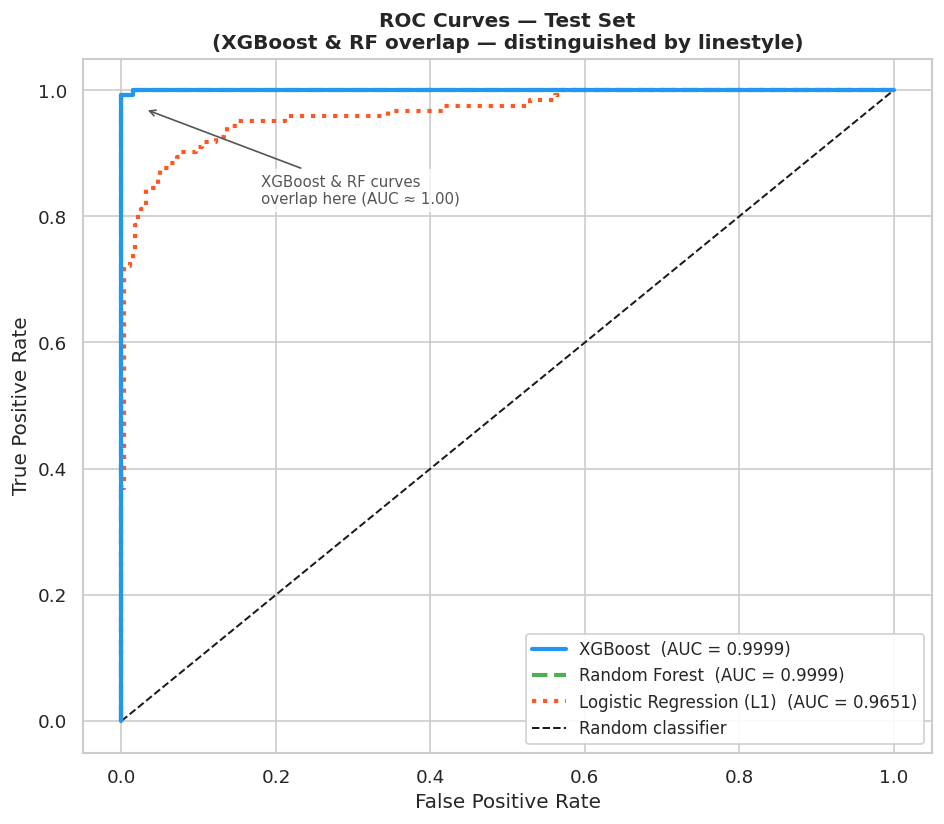

AUC values per model:
  XGBoost                             AUC = 0.9999
  Random Forest                       AUC = 0.9999
  Logistic Regression (L1)            AUC = 0.9651

Note: XGBoost & Random Forest AUCs are near-identical (0.9999).
Their curves visually overlap — linestyles make both visible.


In [28]:
# ── 7.4  ROC Curves ───────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))

# Define per-model style — color + linestyle + linewidth
model_styles = {
    'XGBoost':                    {'color': '#2196F3', 'ls': '-',  'lw': 2.5, 'zorder': 4},
    'Random Forest':              {'color': '#4CAF50', 'ls': '--', 'lw': 2.5, 'zorder': 3},
    'Logistic Regression (L1)':   {'color': '#FF5722', 'ls': ':',  'lw': 2.5, 'zorder': 2},
}

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    style = model_styles[name]
    ax.plot(fpr, tpr,
            color=style['color'],
            linestyle=style['ls'],
            linewidth=style['lw'],
            zorder=style['zorder'],
            label=f"{name}  (AUC = {auc:.4f})")

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random classifier', zorder=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set\n(XGBoost & RF overlap — distinguished by linestyle)',
             fontsize=12, fontweight='bold')

ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

# Annotate the overlap zone
ax.annotate('XGBoost & RF curves\noverlap here (AUC ≈ 1.00)',
            xy=(0.03, 0.97), xytext=(0.18, 0.82),
            fontsize=9, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#555555'),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig('eval_03_roc_curves_fixed.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Quick verification ────────────────────────────────────────────
print("AUC values per model:")
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    print(f"  {name:<35} AUC = {roc_auc_score(y_test, y_prob):.4f}")
print("\nNote: XGBoost & Random Forest AUCs are near-identical (0.9999).")
print("Their curves visually overlap — linestyles make both visible.")


In [31]:
# ── 7.5  Age-stratified accuracy (on test set) ★ ──────────────────
best_model = trained_models['XGBoost']
y_pred_xgb = best_model.predict(X_test_sc)

# Rebuild age test mapping from original df using test indices
age_test_series = age_groups_all.iloc[y_test.index].reset_index(drop=True)
y_test_reset    = y_test.reset_index(drop=True)
y_pred_series   = pd.Series(y_pred_xgb)

strat_res = []
for grp in ['<20','20-25','26-30','31-35','>35']:
    mask = (age_test_series == grp).values
    if mask.sum() == 0:
        continue
    yt = y_test_reset[mask]
    yp = y_pred_series[mask]
    if len(yt.unique()) < 2:
        continue
    strat_res.append({
        'Age Group': grp,
        'N (test)':  mask.sum(),
        'PCOS count': int(yt.sum()),
        'Accuracy':   round(accuracy_score(yt, yp), 4),
        'Recall':     round(recall_score(yt, yp, zero_division=0), 4),
        'F1':         round(f1_score(yt, yp, zero_division=0), 4)
    })

strat_df = pd.DataFrame(strat_res).set_index('Age Group')
print('=== Age-Stratified XGBoost Performance (Test Set) ===')
print(strat_df.to_string())
strat_df

=== Age-Stratified XGBoost Performance (Test Set) ===
           N (test)  PCOS count  Accuracy  Recall      F1
Age Group                                                
20-25            50          24    1.0000  1.0000  1.0000
26-30           132          49    0.9848  1.0000  0.9800
31-35           127          29    0.9921  0.9655  0.9825
>35              91          20    0.9780  1.0000  0.9524


,N (test),PCOS count,Accuracy,Recall,F1
Age Group,,,,,
20-25,50,24,1.0000,1.0000,1.0000
26-30,132,49,0.9848,1.0000,0.9800
31-35,127,29,0.9921,0.9655,0.9825
>35,91,20,0.9780,1.0000,0.9524


## 8. SHAP Root Cause Analysis ★ <a id='shap'></a>
> Which hormones are the primary drivers of PCOS? SHAP assigns each feature a contribution score per prediction. Globally, it tells us which biomarkers matter most.

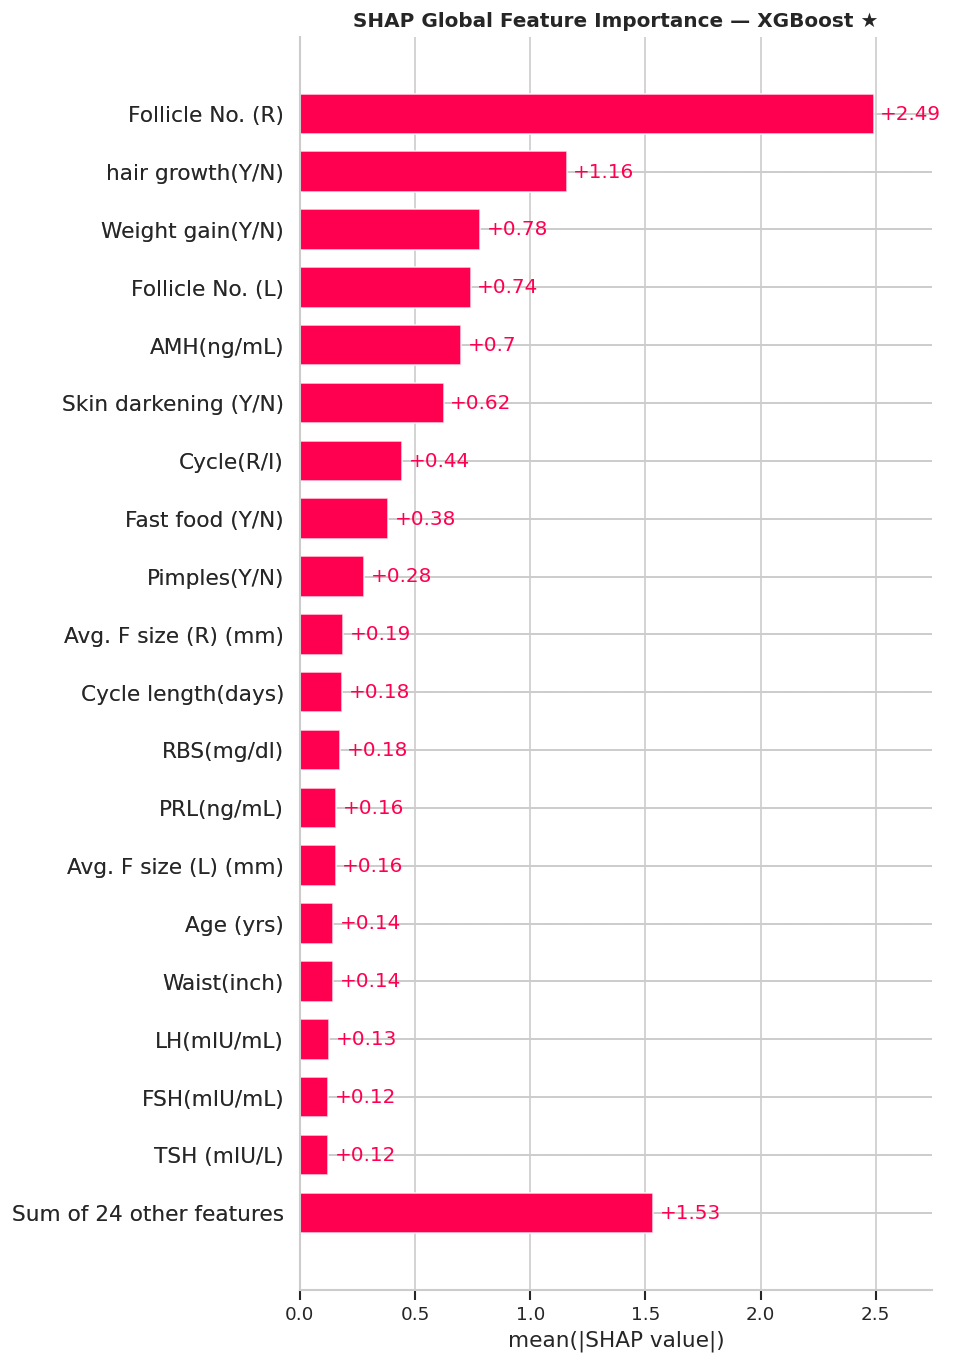

In [32]:
# ── 8.1  SHAP values — XGBoost ───────────────────────────────────
explainer = shap.Explainer(trained_models['XGBoost'],
                            feature_names=X.columns.tolist())
shap_values = explainer(X_test_sc)

# Global bar chart
fig = plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('SHAP Global Feature Importance — XGBoost ★', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_01_bar.png', bbox_inches='tight')
plt.show()

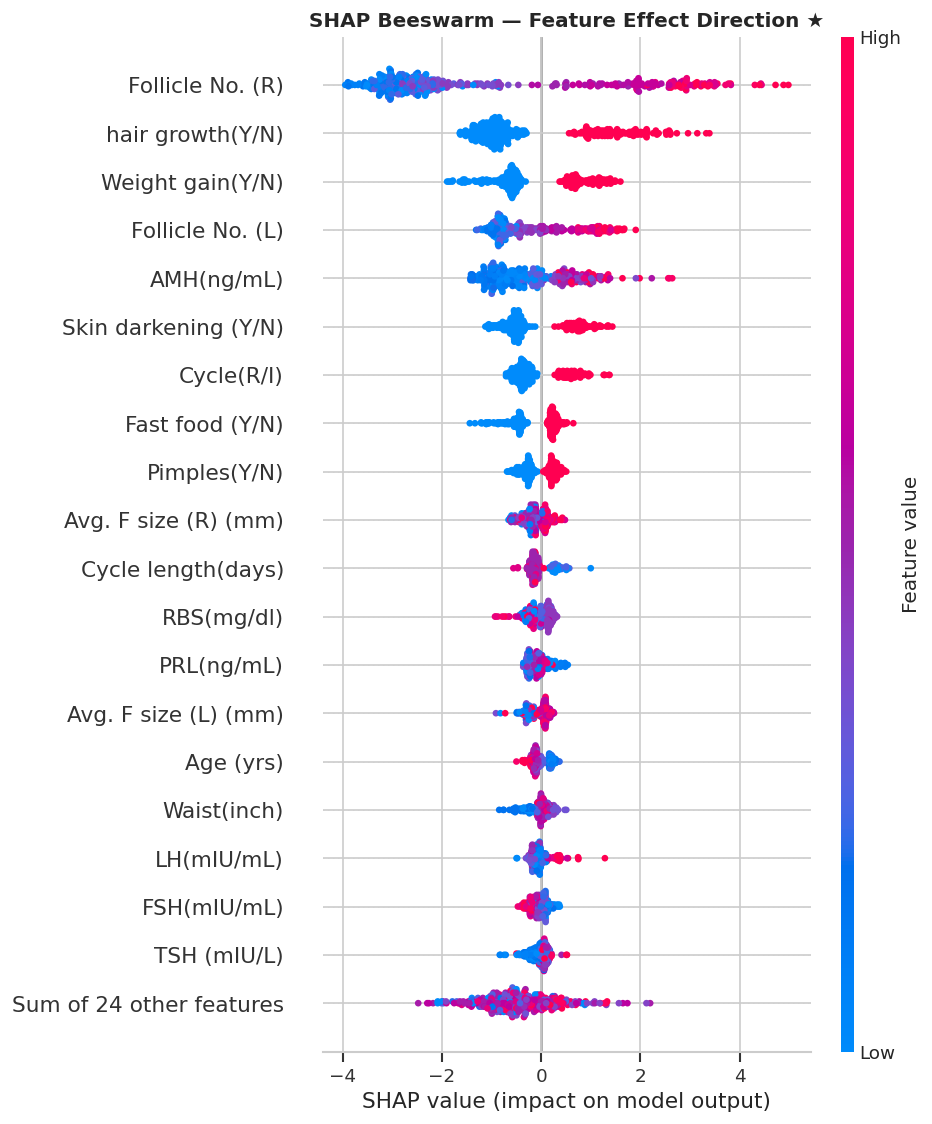

Blue = low feature value → pushes prediction toward Non-PCOS
Red  = high feature value → pushes prediction toward PCOS


In [33]:
# ── 8.2  Beeswarm plot (direction of effect) ──────────────────────
fig = plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Effect Direction ★', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_02_beeswarm.png', bbox_inches='tight')
plt.show()
print('Blue = low feature value → pushes prediction toward Non-PCOS')
print('Red  = high feature value → pushes prediction toward PCOS')

<Figure size 960x600 with 0 Axes>

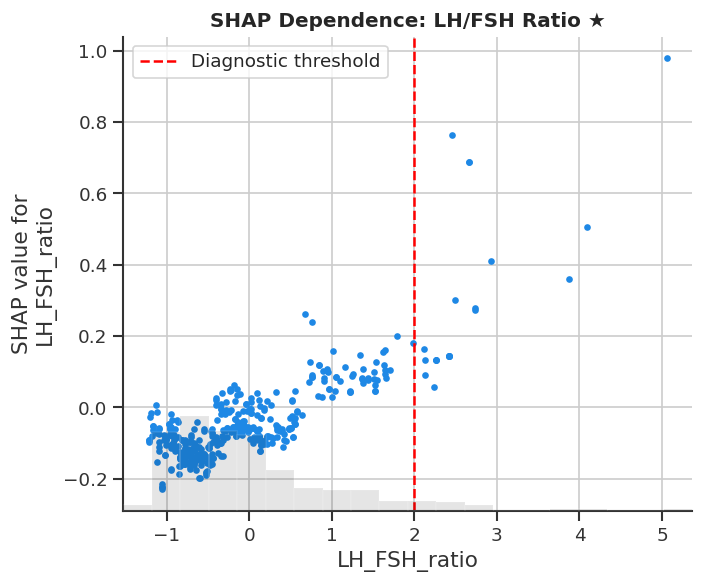

In [34]:
# ── 8.3  SHAP dependence — LH/FSH ratio (key biomarker) ──────────
lh_fsh_idx = list(X.columns).index('LH_FSH_ratio')

fig = plt.figure(figsize=(8, 5))
shap.plots.scatter(shap_values[:, lh_fsh_idx], show=False)
plt.title('SHAP Dependence: LH/FSH Ratio ★', fontweight='bold')
plt.axvline(2.0, color='red', linestyle='--', label='Diagnostic threshold')
plt.legend()
plt.tight_layout()
plt.savefig('shap_03_lh_fsh_dependence.png', bbox_inches='tight')
plt.show()

In [35]:
# ── 8.4  Print ranked root causes ────────────────────────────────
mean_shap = np.abs(shap_values.values).mean(axis=0)
shap_rank = pd.DataFrame({'Feature': X.columns, 'Mean |SHAP|': mean_shap})
shap_rank = shap_rank.sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print('=== PCOS Root Cause Ranking (SHAP) ===')
print(shap_rank.head(15).to_string(index=False))

=== PCOS Root Cause Ranking (SHAP) ===
             Feature  Mean |SHAP|
    Follicle No. (R)     2.490493
    hair growth(Y/N)     1.157911
    Weight gain(Y/N)     0.781050
    Follicle No. (L)     0.741316
          AMH(ng/mL)     0.700394
Skin darkening (Y/N)     0.623843
          Cycle(R/I)     0.443402
     Fast food (Y/N)     0.384698
        Pimples(Y/N)     0.280646
Avg. F size (R) (mm)     0.189084
  Cycle length(days)     0.182143
          RBS(mg/dl)     0.175626
          PRL(ng/mL)     0.158672
Avg. F size (L) (mm)     0.155037
           Age (yrs)     0.143364


---
# PART 2 — Ultrasound Image Dataset
**Dataset:** Train/Test folders · Classes: `infected` (PCOS) · `notinfected` (Healthy)
**Models:** ResNet-50 · EfficientNet-B3 · VGG-16 (all pretrained on ImageNet, fine-tuned)

## 9. Image Setup & Paths <a id='imgsetup'></a>

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import os, cv2, torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import timm  # for EfficientNet

# ── CHANGE THESE PATHS to your dataset location ──────────────────
TRAIN_DIR = '/content/drive/MyDrive/data/train'   # subfolders: infected / notinfected
TEST_DIR  = '/content/drive/MyDrive/data/test'    # subfolders: infected / notinfected
# ─────────────────────────────────────────────────────────────────

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-4
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASS_MAP  = {'infected': 1, 'notinfected': 0}  # adjust if folder names differ

print(f'Device : {DEVICE}')
print(f'CUDA   : {torch.cuda.is_available()}')

# Count images
for split, path in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    for cls in ['infected', 'notinfected']:
        cls_path = os.path.join(path, cls)
        n = len(os.listdir(cls_path)) if os.path.exists(cls_path) else 0
        print(f'  {split} / {cls}: {n} images')

Device : cpu
CUDA   : False
  Train / infected: 781 images
  Train / notinfected: 1143 images
  Test / infected: 787 images
  Test / notinfected: 1145 images


## 10. Image Preprocessing & EDA <a id='imgpreprocess'></a>

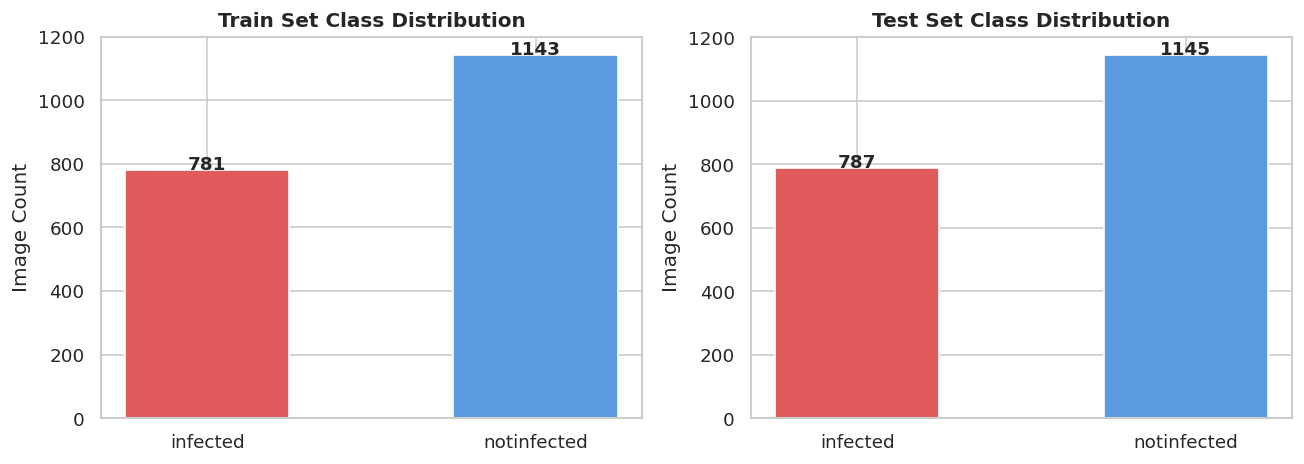

In [41]:
# ── 10.1  Class distribution bar chart ───────────────────────────
counts = {}
for split, path in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    counts[split] = {}
    for cls in ['infected', 'notinfected']:
        p = os.path.join(path, cls)
        counts[split][cls] = len(os.listdir(p)) if os.path.exists(p) else 0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (split, cnt) in zip(axes, counts.items()):
    bars = ax.bar(cnt.keys(), cnt.values(),
                  color=[COLORS['pcos'], COLORS['healthy']],
                  edgecolor='white', width=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                int(bar.get_height()), ha='center', fontweight='bold')
    ax.set_title(f'{split} Set Class Distribution', fontweight='bold')
    ax.set_ylabel('Image Count')

plt.tight_layout()
plt.savefig('img_eda_01_class_distribution.png', bbox_inches='tight')
plt.show()

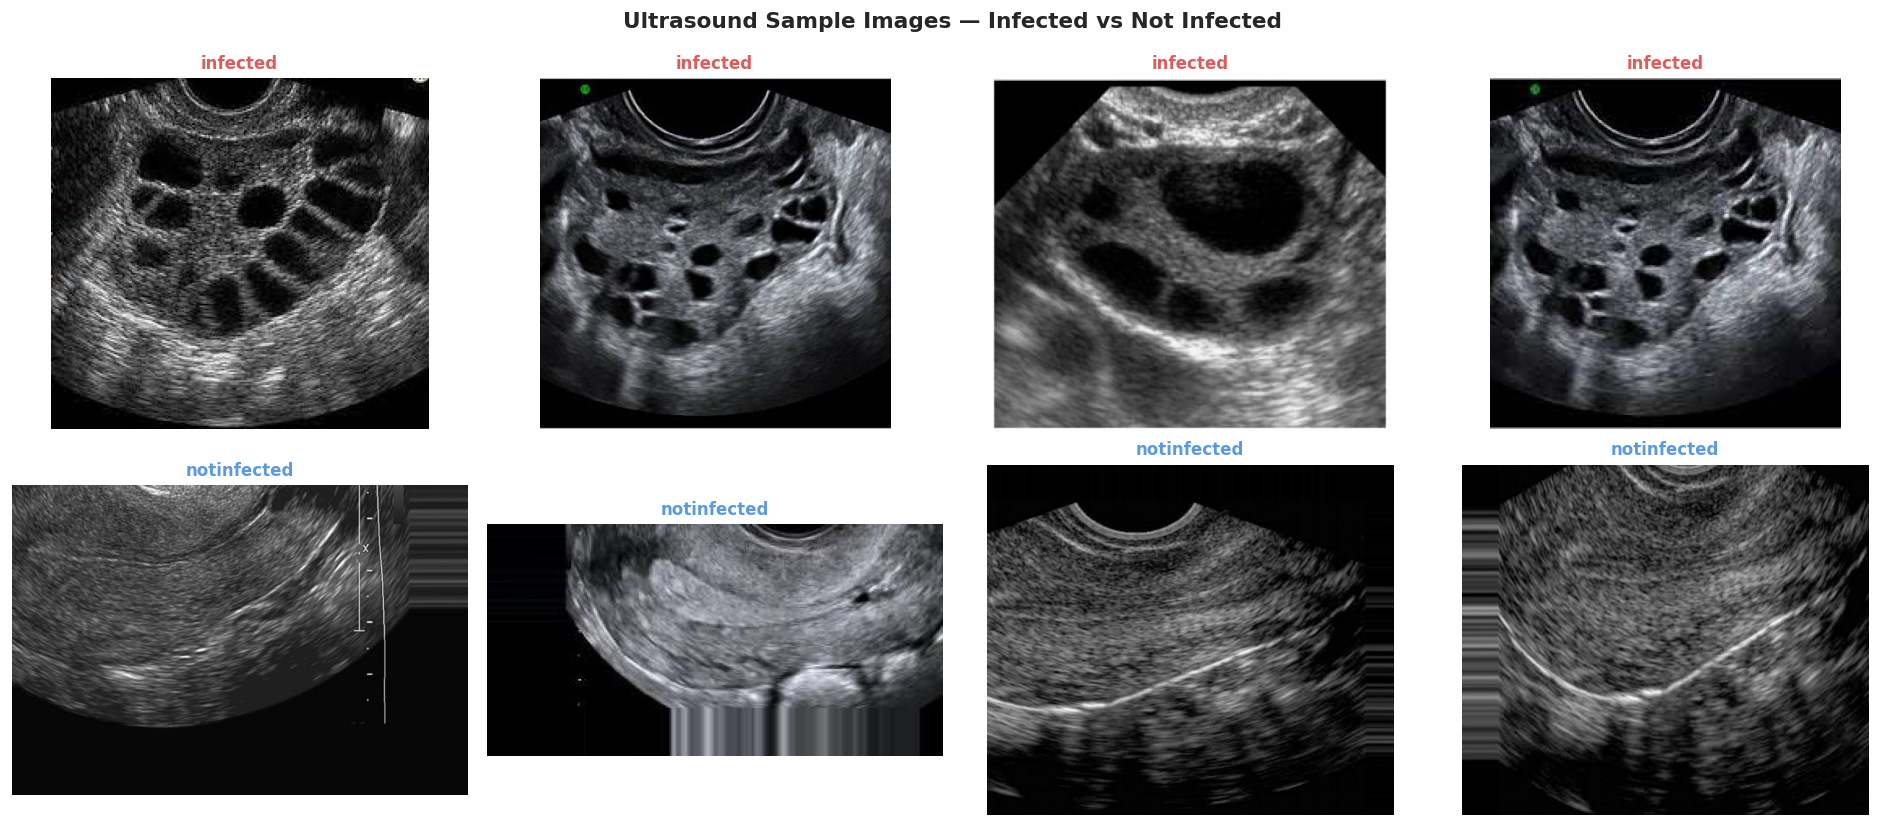

In [42]:
# ── 10.2  Sample image grid ───────────────────────────────────────
def load_sample_images(folder, n=4):
    imgs = []
    files = [f for f in os.listdir(folder) if f.lower().endswith(
             ('.png','.jpg','.jpeg','.bmp'))][:n]
    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs.append(img)
    return imgs

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for row, cls in enumerate(['infected', 'notinfected']):
    imgs = load_sample_images(os.path.join(TRAIN_DIR, cls), n=4)
    for col, img in enumerate(imgs):
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(cls, fontsize=10, fontweight='bold',
                                  color=COLORS['pcos'] if cls=='infected' else COLORS['healthy'])
        axes[row][col].axis('off')

plt.suptitle('Ultrasound Sample Images — Infected vs Not Infected',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img_eda_02_samples.png', bbox_inches='tight')
plt.show()

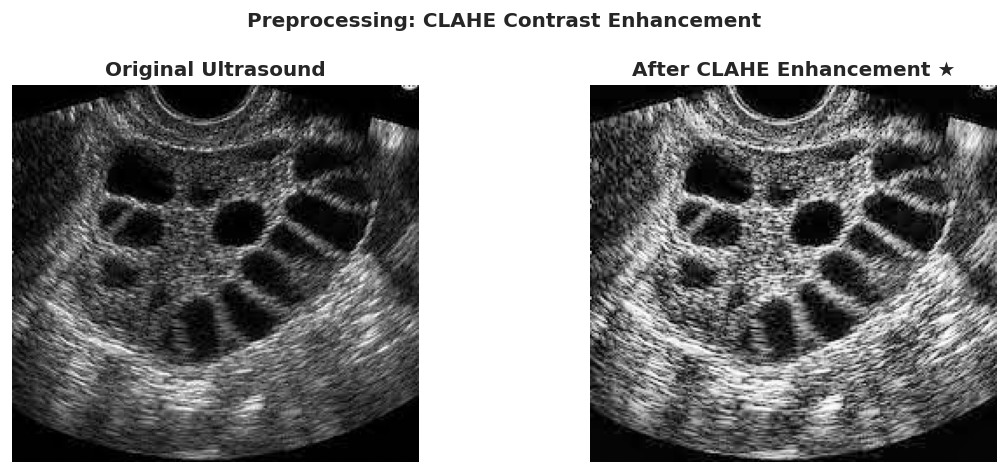

In [43]:
# ── 10.3  CLAHE enhancement — before/after ★ ─────────────────────
sample_path = os.path.join(TRAIN_DIR, 'infected',
    os.listdir(os.path.join(TRAIN_DIR, 'infected'))[0])
img_bgr  = cv2.imread(sample_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray,  cmap='gray'); axes[0].set_title('Original Ultrasound', fontweight='bold')
axes[1].imshow(img_clahe, cmap='gray'); axes[1].set_title('After CLAHE Enhancement ★', fontweight='bold')
for ax in axes: ax.axis('off')

plt.suptitle('Preprocessing: CLAHE Contrast Enhancement', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('img_eda_03_clahe.png', bbox_inches='tight')
plt.show()

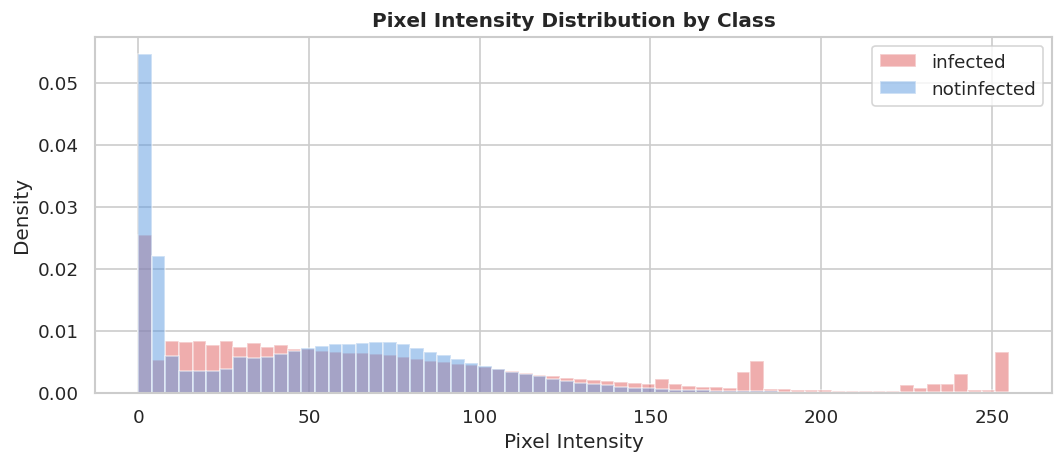

In [44]:
# ── 10.4  Pixel intensity histograms ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

for cls, color in [('infected', COLORS['pcos']), ('notinfected', COLORS['healthy'])]:
    all_pixels = []
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir)[:50]:  # sample 50 for speed
        img = cv2.imread(os.path.join(cls_dir, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_pixels.extend(img.flatten().tolist())
    ax.hist(all_pixels, bins=64, alpha=0.5, color=color,
            label=cls, density=True)

ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Density')
ax.set_title('Pixel Intensity Distribution by Class', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('img_eda_04_pixel_hist.png', bbox_inches='tight')
plt.show()

In [45]:
# ── 10.5  Define transforms ───────────────────────────────────────
# ImageNet mean/std (used for all pretrained models)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print('Transforms defined ✓')
print('Train: Resize → Flip → Rotate → ColorJitter → Normalize')
print('Test : Resize → Normalize (no augmentation)')

Transforms defined ✓
Train: Resize → Flip → Rotate → ColorJitter → Normalize
Test : Resize → Normalize (no augmentation)


In [49]:
# ── 10.6  Custom Dataset class ────────────────────────────────────
class PCOSDataset(Dataset):
    def __init__(self, root_dir, transform=None, apply_clahe=True):
        self.samples = []
        self.transform = transform
        self.apply_clahe = apply_clahe
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

        for cls_name, label in CLASS_MAP.items():
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.exists(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if not fname.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
                    continue
                full_path = os.path.join(cls_dir, fname)
                # Try to read the image; skip if corrupted
                test_img = cv2.imread(full_path)
                if test_img is None:
                    print(f"⚠️ Skipping unreadable image: {full_path}")
                    continue
                self.samples.append((full_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        # No need for extra check now because we already validated in __init__
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.apply_clahe:
            channels = [self.clahe.apply(img[:,:,c]) for c in range(3)]
            img = np.stack(channels, axis=2)

        img_pil = Image.fromarray(img)
        if self.transform:
            img_pil = self.transform(img_pil)
        return img_pil, label

train_dataset = PCOSDataset(TRAIN_DIR, transform=train_transforms, apply_clahe=True)
test_dataset  = PCOSDataset(TEST_DIR,  transform=test_transforms,  apply_clahe=True)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train samples: {len(train_dataset)}')
print(f'Test  samples: {len(test_dataset)}')

⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.20 PM.jpeg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.05 PM.jpeg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/infected/OIP.jpg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/infected/WhatsApp Image 2022-04-01 at 3.49.22 PM.jpeg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/infected/R.jpg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/infected/WhatsApp Image 2022-04-01 at 3.49.45 PM.jpeg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/notinfected/img_0_7.jpg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/notinfected/WhatsApp Image 2022-04-01 at 3.35.25 PM.jpeg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/notinfected/OIP (1).jpg
⚠️ Skipping unreadable image: /content/drive/MyDrive/data/test/notinfected/Whats

## 11. CNN Model Training <a id='cnn'></a>

In [51]:
# ── Helper functions ──────────────────────────────────────────────
def build_model(arch):
    """Build pretrained model with custom classifier head."""
    if arch == 'resnet50':
        m = models.resnet50(weights='IMAGENET1K_V2')
        # Freeze early layers, fine-tune last 2 blocks
        for name, param in m.named_parameters():
            if 'layer4' not in name and 'layer3' not in name and 'fc' not in name:
                param.requires_grad = False
        m.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(m.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    elif arch == 'efficientnet_b3':
        m = timm.create_model('efficientnet_b3', pretrained=True, num_classes=2)
        # Freeze most layers
        for name, param in m.named_parameters():
            if 'blocks.6' not in name and 'blocks.5' not in name and 'classifier' not in name:
                param.requires_grad = False

    elif arch == 'vgg16':
        m = models.vgg16(weights='IMAGENET1K_V1')
        for param in m.features.parameters():
            param.requires_grad = False  # freeze conv layers
        m.classifier[6] = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(4096, 2)
        )

    return m.to(DEVICE)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            probs = torch.softmax(out, dim=1)[:, 1]
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (total_loss/total, correct/total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

print('Helper functions defined ✓')

Helper functions defined ✓


In [52]:
from torch.optim.lr_scheduler import CosineAnnealingLR

cnn_trained = {}
cnn_histories = {}
cnn_results   = []

architectures = {
    'ResNet-50':       'resnet50',
    'EfficientNet-B3': 'efficientnet_b3',
    'VGG-16':          'vgg16'
}

# Class weights for imbalance
class_counts = [counts['Train']['notinfected'], counts['Train']['infected']]
weights = torch.tensor([1.0/c for c in class_counts], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

for model_name, arch in architectures.items():
    print(f'\n{'='*50}')
    print(f'Training: {model_name}')
    print(f'{'='*50}')

    model     = build_model(arch)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc, best_state = 0, None

    for epoch in range(1, EPOCHS+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _, _ = evaluate(model, test_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = model.state_dict().copy()

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{EPOCHS} | '
                  f'Train: loss={tr_loss:.4f} acc={tr_acc:.4f} | '
                  f'Val: loss={vl_loss:.4f} acc={vl_acc:.4f}')

    # Load best weights
    model.load_state_dict(best_state)
    cnn_trained[model_name]   = model
    cnn_histories[model_name] = history

    # Final test evaluation
    _, _, y_pred, y_true, y_prob = evaluate(model, test_loader, criterion)
    cnn_results.append({
        'Model':     model_name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_true, y_prob)
    })
    # Save model
    torch.save(best_state, f'{arch}_best.pth')
    print(f'  Best val acc: {best_val_acc:.4f} — saved to {arch}_best.pth')

print('\nAll CNN models trained ✓')


Training: ResNet-50
  Epoch   1/20 | Train: loss=0.2185 acc=0.9241 | Val: loss=0.0007 acc=1.0000


KeyboardInterrupt: 

## 12. CNN Evaluation & Grad-CAM ★ <a id='gradcam'></a>

In [ ]:
# ── 12.1  Training curves ─────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
colors_cnn = {'ResNet-50': '#2196F3', 'EfficientNet-B3': '#4CAF50', 'VGG-16': '#FF5722'}

for row, mname in enumerate(architectures.keys()):
    h = cnn_histories[mname]
    ax_loss, ax_acc = axes[row]

    ax_loss.plot(h['train_loss'], label='Train', color=colors_cnn[mname])
    ax_loss.plot(h['val_loss'],   label='Val',   color=colors_cnn[mname], linestyle='--')
    ax_loss.set_title(f'{mname} — Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend()

    ax_acc.plot(h['train_acc'], label='Train', color=colors_cnn[mname])
    ax_acc.plot(h['val_acc'],   label='Val',   color=colors_cnn[mname], linestyle='--')
    ax_acc.set_title(f'{mname} — Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

plt.suptitle('CNN Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_01_training_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 12.2  CNN results table ───────────────────────────────────────
cnn_df = pd.DataFrame(cnn_results).set_index('Model').round(4)
print('=== CNN Test Set Performance ===')
print(cnn_df.to_string())
cnn_df

In [ ]:
# ── 12.3  CNN confusion matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (mname, model) in zip(axes, cnn_trained.items()):
    _, _, y_pred, y_true, _ = evaluate(model, test_loader, criterion)
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Healthy','PCOS']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(mname, fontweight='bold')

plt.suptitle('CNN Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_02_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 12.4  Grad-CAM Visualization ★ ───────────────────────────────
# We implement a lightweight Grad-CAM without external dependencies

class GradCAM:
    def __init__(self, model, target_layer):
        self.model    = model
        self.grads    = None
        self.acts     = None
        self.hooks    = []

        self.hooks.append(
            target_layer.register_forward_hook(self._save_activation))
        self.hooks.append(
            target_layer.register_full_backward_hook(self._save_gradient))

    def _save_activation(self, _, __, output):
        self.acts = output.detach()

    def _save_gradient(self, _, __, grad_output):
        self.grads = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()

        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.acts).sum(dim=1).squeeze()
        cam     = torch.clamp(cam, min=0)
        cam     = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()

    def remove_hooks(self):
        for h in self.hooks: h.remove()


def get_target_layer(model, arch_name):
    if arch_name == 'ResNet-50':
        return model.layer4[-1]  # last ResNet block
    elif arch_name == 'EfficientNet-B3':
        return model.blocks[-1][-1]  # last efficient block
    elif arch_name == 'VGG-16':
        return model.features[-1]  # last conv layer


def overlay_heatmap(img_tensor, cam, alpha=0.5):
    """Overlay Grad-CAM heatmap on original image."""
    img_np = img_tensor.squeeze().permute(1,2,0).cpu().numpy()
    # Denormalize
    img_np = img_np * np.array(STD) + np.array(MEAN)
    img_np = np.clip(img_np, 0, 1)

    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = alpha * heatmap + (1 - alpha) * img_np
    return np.clip(overlay, 0, 1)


# Generate Grad-CAM for best model (ResNet-50) on 4 infected samples
best_cnn_name = max(cnn_results, key=lambda x: x['AUC-ROC'])['Model']
best_cnn_arch = architectures[best_cnn_name]
print(f'Generating Grad-CAM for best model: {best_cnn_name}')

best_cnn = cnn_trained[best_cnn_name]
target_layer = get_target_layer(best_cnn, best_cnn_name)
gcam = GradCAM(best_cnn, target_layer)

infected_dir = os.path.join(TEST_DIR, 'infected')
sample_files = [f for f in os.listdir(infected_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))][:4]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, fname in enumerate(sample_files):
    img_path = os.path.join(infected_dir, fname)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img)
    img_tensor = test_transforms(img_pil).unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)

    cam = gcam.generate(img_tensor, class_idx=1)  # 1 = infected/PCOS
    overlay = overlay_heatmap(img_tensor.detach(), cam)

    axes[0][i].imshow(img)
    axes[0][i].set_title(f'Original #{i+1}', fontsize=10)
    axes[0][i].axis('off')

    axes[1][i].imshow(overlay)
    axes[1][i].set_title(f'Grad-CAM #{i+1}', fontsize=10, color='red', fontweight='bold')
    axes[1][i].axis('off')

gcam.remove_hooks()
plt.suptitle(f'Grad-CAM Cyst Localization — {best_cnn_name} ★\n'
             '(Red = regions driving PCOS detection)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_03_gradcam.png', bbox_inches='tight')
plt.show()

---
# PART 3 — Final Comparison & Summary
## 13. Combined Results <a id='summary'></a>

In [ ]:
# ── 13.1  Combined performance table ─────────────────────────────
print('\n' + '='*65)
print('       PART 1 — Tabular Clinical Models (Test Set)            ')
print('='*65)
print(results_df.round(4).to_string())

print('\n' + '='*65)
print('       PART 2 — CNN Ultrasound Models (Test Set)              ')
print('='*65)
print(cnn_df.round(4).to_string())

print('\n' + '='*65)
print('       Age-Stratified XGBoost Performance                     ')
print('='*65)
print(strat_df.to_string())

In [ ]:
# ── 13.2  Final radar/bar comparison (all 6 models) ──────────────
all_models = pd.concat([
    results_df[['Accuracy','Precision','Recall','F1-Score','AUC-ROC']],
    cnn_df[['Accuracy','Precision','Recall','F1-Score','AUC-ROC']]
])

fig, ax = plt.subplots(figsize=(14, 5))
metrics  = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
x        = np.arange(len(metrics))
n_models = len(all_models)
width    = 0.12
palette6 = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#FF5722']

for i, (mname, row) in enumerate(all_models.iterrows()):
    ax.bar(x + i*width, row[metrics], width,
           label=mname, color=palette6[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * (n_models/2 - 0.5))
ax.set_xticklabels(metrics)
ax.set_ylim(0.4, 1.1)
ax.set_ylabel('Score')
ax.set_title('All 6 Models — Final Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(0.9, color='grey', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('summary_01_all_models.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 13.3  Top SHAP root causes — summary print ────────────────────
print('\n=== ROOT CAUSE ANALYSIS SUMMARY ===')
print('Top 10 hormonal/clinical drivers of PCOS (XGBoost SHAP):')
print('-'*45)
for _, row in shap_rank.head(10).iterrows():
    bar = '█' * int(row['Mean |SHAP|'] / shap_rank['Mean |SHAP|'].max() * 30)
    print(f"  {row['Feature']:<30}  {bar}  {row['Mean |SHAP|']:.4f}")

print('\n=== PAPER CONTRIBUTION CHECKLIST ===')
print('  ✓ Tabular preprocessing (imputation, SMOTE, scaling)')
print('  ✓ Image preprocessing (CLAHE, augmentation, normalization)')
print('  ✓ Exploratory Data Analysis (8 tabular + 4 image plots)')
print('  ✓ Age-stratified analysis (5 age bands, prevalence + performance)')
print('  ✓ 3 tabular models trained and evaluated')
print('  ✓ 3 CNN models trained and evaluated')
print('  ✓ SHAP root cause analysis (global bar + beeswarm + dependence)')
print('  ✓ Grad-CAM cyst localization')
print('  ✓ 5-fold stratified cross-validation')
print('  ✓ Full evaluation suite (accuracy, precision, recall, F1, AUC-ROC)')